<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/ECMWF_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECMWF Project

## About ECMWF: European Centre for Medium-Range Weather Forecasts

## Overview

The **European Centre for Medium-Range Weather Forecasts (ECMWF)** is an independent intergovernmental organization supported by 35 European countries. Founded in 1975, it is one of the world’s leading centers for global numerical weather prediction and atmospheric research. 23 European countries (founding and contributing members) are member states.
12 additional nations (through collaboration agreements) are cooperative states. Funding is financed by member states jointly.

ECMWF is known for:
- Producing some of the **most accurate global weather forecasts**.
- Operating powerful supercomputers for data assimilation and simulation.
- Providing essential data to national meteorological services, researchers, and institutions.

**Official website**: [https://www.ecmwf.int](https://www.ecmwf.int)


## Mission and Objetives

> *“To produce global numerical weather forecasts and conduct scientific and technical research to improve forecasting.”*

ECMWF supports:
- **Medium-range weather forecasting** (up to 15 days)
- **Sub-seasonal and seasonal forecasting**
- **Reanalysis datasets** (e.g., ERA5)
- **Climate monitoring and atmospheric composition**
- **Severe weather support and emergency response**  
- **Continuously improve numerical models through scientific research and technological development**  



## Types of Forecast Products
ECMWF operates several forecasting systems, each with specific applications:  

### A. **High-Resolution Forecasts (HRES)**
- Single deterministic forecasts
- 9 km horizontal resolution (since 2023, previously ~18 km)
- 15-day forecasts updated twice daily
- Atmospheric variables:
  - Temperature, pressure, wind (at multiple levels).  
  - Precipitation, humidity, cloud cover.  
  - Surface parameters (waves, soil temperature, etc.).

### B. **Ensemble Forecasts (ENS - Ensemble Prediction System)**
- 51-member forecast ensemble (1 control + 50 perturbed runs)
- Measures forecast uncertainty
- ~18 km (days 1-15), ~36 km (days 16-46).
- Used for probabilistic prediction up to 46 days. Quantify forecast uncertainty through initial condition and model perturbations.
- Early warnings for extreme events (hurricanes, heatwaves).
- Probability-based forecasts (e.g., rainfall likelihood).

### C. **Ocean Wave Model Forecasts (WAM)**
- Simulations of **wave height**, **direction**, and **period**
- Coupled to atmospheric model
- Products:
  - HRES-WAM: deterministic, high-resolution ocean wave forecast
  - ENS-WAM: ensemble wave forecast

### D. **Seasonal Forecasts (SEAS)**
- Climate-scale predictions up to 7 months ahead
- Key Components:  
  - Ocean-atmosphere interactions.  
  - Sea ice and ocean temperature data.
- Useful for agriculture, energy, and water management

### E. **Climate Reanalysis (ERA5)**  
- **ERA5**: High-resolution global reanalysis (31 km, hourly data since 1959).  
- **Variables**: 200+ atmospheric, land, and oceanic parameters.  
- **Applications**:  
  - Climate change studies.  
  - Model validation.  
  - Renewable energy (wind/solar) assessments.

## Technological Infrastructure  
### **Supercomputing**  
- **Current Capacity**:  
  - **Atos BullSequana**: ~350 petaflops (as of 2023).  
  - Massive storage for model data and observations.  
- **Challenges**:  
  - Processing meteorological Big Data (satellites, radars, buoys).  
  - Real-time data assimilation.  

### **Data Assimilation (4D-Var)**  
- **Technique**: 4D-Var (Four-Dimensional Variational Assimilation).  
- **Data Sources**:  
  - Satellites (e.g., Copernicus, MetOp).  
  - Radiosondes, aircraft, ocean buoys.  
  - Surface observations.


## Data Access and Formats

### 1. **Copernicus Climate Data Store (CDS)**
Access to:
- ERA5 reanalysis data
- Climate indicators
- Forecasts and satellite-derived datasets

[Copernicus Climate Data Store](https://cds.climate.copernicus.eu/)

Requires:
- Free user registration
- Python client: `cdsapi`

### 2. **ECMWF Open Data Portal**
Provides open access to a subset of HRES forecast data.

[https://www.ecmwf.int/en/forecasts/datasets/open-data](https://www.ecmwf.int/en/forecasts/datasets/open-data)

No login or API key required.

### 3. **Real-time License Access**
For licensed users (e.g., national weather services, academic institutions), ECMWF provides full access to real-time operational forecasts.

[Real-Time Data Catalogue](https://www.ecmwf.int/en/forecasts/datasets/catalogue-ecmwf-real-time-products)


## Data Formats

ECMWF data comes in two main formats:
- **GRIB** (GRIdded Binary): compact, efficient format for meteorological fields.
  - Used for operational forecasts
  - Readable with tools like `cfgrib`, `eccodes`, `metview`
- **NetCDF**: common in climate and oceanography.
  - Used mostly in reanalysis products like ERA5


## Tools and Libraries

| Tool / Library     | Purpose                                     | Link |
|--------------------|---------------------------------------------|------|
| `cdsapi`           | Python client for Copernicus API            | [GitHub](https://github.com/ecmwf/cdsapi) |
| `ecmwf-opendata`   | Python access to ECMWF open forecasts       | [GitHub](https://github.com/ecmwf/ecmwf-opendata) |
| `metview`          | Meteorological analysis and visualization   | [Metview](https://confluence.ecmwf.int/display/METV/Metview) |
| `cfgrib`           | Interface for reading GRIB files with xarray| [cfgrib](https://github.com/ecmwf/cfgrib) |
| `eccodes`          | C library + Python bindings for GRIB/BUFR   | [ecCodes](https://confluence.ecmwf.int/display/ECC/ecCodes+Home) |



## Example Variables You Can Retrieve

### Atmosphere:
- `2t`: 2m temperature
- `u10`, `v10`: 10m wind components
- `msl`: mean sea level pressure
- `tcc`: total cloud cover

### Ocean / Wave:
- `swh`: Significant wave height
- `mwd`: Mean wave direction
- `pp1d`: Peak wave period


## How to Get Started with ECMWF Data

### Step 1: Register for Copernicus
- Go to [https://cds.climate.copernicus.eu/](https://cds.climate.copernicus.eu/)
- Create an account and accept license terms

### Step 2: Install the API client


In [1]:
!pip install cdsapi cfgrib xarray netCDF4 cartopy matplotlib plotly --quiet


In [2]:
import os

# Paste your password between the triple quotes
cdsapirc = """
url: https://cds.climate.copernicus.eu/api
key: 697a15cd-dedc-492d-8df6-80d489fb8bcf
"""

# Save the configuration file
with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(cdsapirc.strip())

---
**Setting our Home**

---

_``We save the root directory of our workspace``_ `'/content'` as `'HOME'` since we will be navigating through the directory to have multiple projects under the same HOME. Additionally, we will have the datasets in the 'datasets' directory, so all datasets are easily accessible for any project.

In [3]:
# Setting our $HOME to /content
import os
HOME = os.getcwd() # Obtain actual directory
print(HOME)

/content


---
**Mount Google Drive**

---

Next, it _``imports the drive module from the `` `google.colab` ``library``_, which provides functionalities for mounting Google Drive in Google Colab.

Additionally, Google Drive is mounted in Google Colab and made available at the path `/content/drive`. `The user will be prompted to authorize access` to Google Drive. Once authorized, the content of Google Drive will be accessible from that point onwards in the Colab notebook.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 3: Download Wave + Wind Data (ERA5)
This example downloads:

- significant_height_of_combined_wind_waves_and_swell (wave height)

- 10m_u_component_of_wind, 10m_v_component_of_wind (wind components)

For:

- Date: July 1, 2024

- Time: 12:00 UTC

- Region: Western Europe Atlantic Coast [60N, -30W, 30N, 30E]


---
**Create a directory where we can save our dataset**

---

Create the dataset directory (only if it doesn't exist), where we are going to save the dataset with which we are going to work.

In [6]:
# Create the dataset directory
import os
datasets_dir = os.path.join(HOME, "datasets")
os.makedirs(datasets_dir, exist_ok=True)
print(os.getcwd())

/content



---
**Change to new directory datasets**

---

Check if the file specified by `file` does not exist in the current directory. If it doesn't exist, the code block inside the conditional, which in this case would be downloading the file from the specified URL, is executed. then, it extracts the contents of `era5_wind_wave.nc` into the current directory quietly, overwriting any existing files if necessary.

In [7]:
# Change to new dataset folder
os.chdir(datasets_dir)
print('dataset_dir =', os.getcwd())

dataset_dir = /content/datasets


---
**Load the dataset**

---

In [8]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
            'significant_height_of_combined_wind_waves_and_swell'
        ],
        'year': '2024',
        'month': '07',
        'day': '01',
        'time': ['12:00'],
        'area': [60, -30, 30, 30],  # [North, West, South, East]
    },
    'era5_wind_wave.nc'
)


2025-07-16 10:56:49,090 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-16 10:56:49,772 INFO Request ID is 17e4b243-a0c7-48ce-856a-55e1dbecd2fd
INFO:ecmwf.datastores.legacy_client:Request ID is 17e4b243-a0c7-48ce-856a-55e1dbecd2fd
2025-07-16 10:56:49,922 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-07-16 10:57:03,962 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e39cf2328f7a30e677627ee3495e3244.zip:   0%|          | 0.00/195k [00:00<?, ?B/s]

'era5_wind_wave.nc'

---
**Unzip the dataset .nc**

---

The '$' symbol allows access to Python variables within shell commands (such as !unzip).


In [22]:
import zipfile
import os

nc_file_path = os.path.join(datasets_dir,"era5_wind_wave.nc")
extracted_dir = os.path.join(datasets_dir,"extracted_data")

!unzip -qq -o "$nc_file_path" -d "$extracted_dir"

In [24]:
!apt-get install tree

!tree "$extracted_dir" -L 1

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/content/datasets/extracted_data
├── data_stream-oper_stepType-instant.nc
└── data_stream-wave_stepType-instant.nc

0 directories, 2 files


---
**Open and explore the NetCDF file**

---

In [30]:
import xarray as xr

# Wave dataset
wave_ds = xr.open_dataset(os.path.join(extracted_dir,'data_stream-wave_stepType-instant.nc'))

# Show information about wave dataset
wave_ds


<xarray.Dataset> Size: 31kB
Dimensions:     (valid_time: 1, latitude: 61, longitude: 121)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-07-01T12:00:00
  * latitude    (latitude) float64 488B 60.0 59.5 59.0 58.5 ... 31.0 30.5 30.0
  * longitude   (longitude) float64 968B -30.0 -29.5 -29.0 ... 29.0 29.5 30.0
    expver      <U4 16B ...
Data variables:
    swh         (valid_time, latitude, longitude) float32 30kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-15T17:06 GRIB to CDM+CF via cfgrib-0.9.1...

In [33]:
# Wind dataset
wind_ds = xr.open_dataset(os.path.join(extracted_dir,'data_stream-oper_stepType-instant.nc'))

# Show information about wave dataset
wind_ds

<xarray.Dataset> Size: 236kB
Dimensions:     (valid_time: 1, latitude: 121, longitude: 241)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-07-01T12:00:00
  * latitude    (latitude) float64 968B 60.0 59.75 59.5 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 2kB -30.0 -29.75 -29.5 ... 29.5 29.75 30.0
    expver      <U4 16B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 117kB ...
    v10         (valid_time, latitude, longitude) float32 117kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-15T17:06 GRIB to CDM+CF via cfgrib-0.9.1...

### Step 6: Plot Significant Wave Height (SWH)

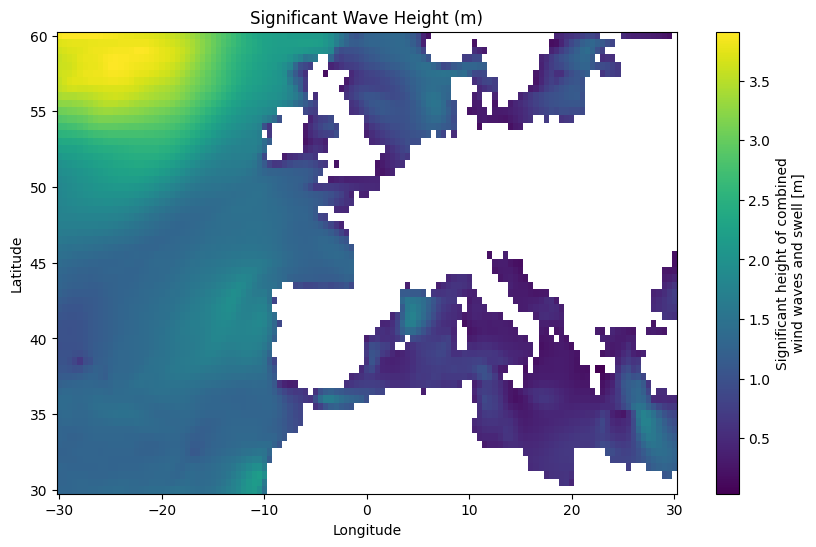

In [36]:
import matplotlib.pyplot as plt

swh = wave_ds['swh'].isel(valid_time=0)

plt.figure(figsize=(10,6))
swh.plot(cmap="viridis")
plt.title("Significant Wave Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


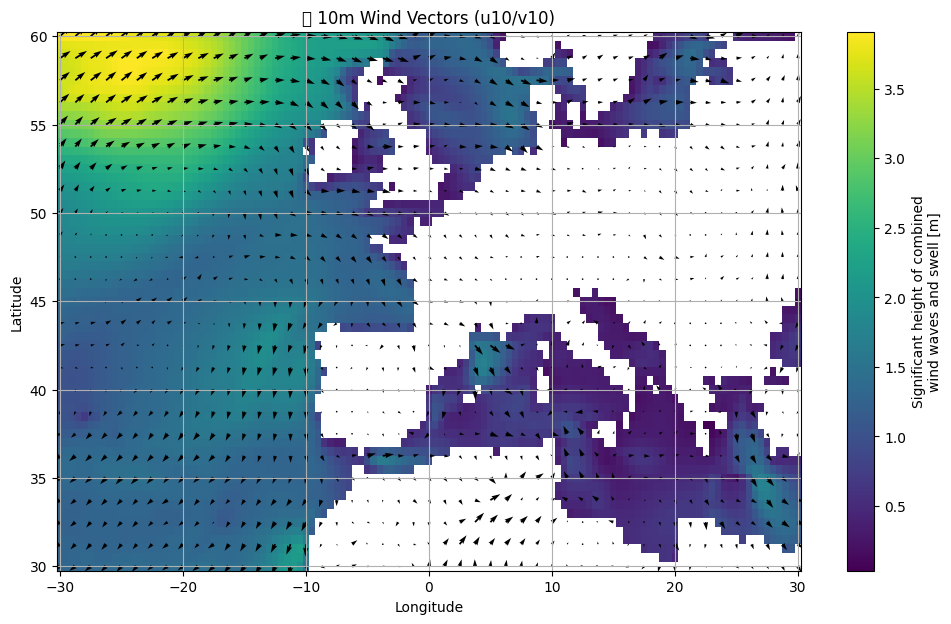

In [35]:
u10 = wind_ds['u10'].isel(valid_time=0)
v10 = wind_ds['v10'].isel(valid_time=0)

# Downsample for readability
u_plot = u10[::5, ::5]
v_plot = v10[::5, ::5]
lon = u_plot.longitude
lat = u_plot.latitude

plt.figure(figsize=(12, 7))
swh.plot(cmap="viridis")
plt.quiver(lon, lat, u_plot, v_plot, scale=700)
plt.title("🌬️ 10m Wind Vectors (u10/v10)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()
